# Exploratory Data Analysis — Sensor Selection for RUL Prediction (FD003)

**Project:** Bayesian Digital Twins for Predictive Maintenance
**Sub-dataset:** FD003 — 1 operating condition, HPC degradation + Fan degradation
**Input:** 14 informative sensors identified in `IDA_FD003.ipynb` (7 constant sensors already excluded, using the project-wide convention established in `Improved_IDA.ipynb`)
**Goal:** Rank and select sensors that carry reliable degradation signal for RUL prediction, using FD003 alone (same 5-criterion methodology as `Improved_EDA.ipynb`, applied here to a single sub-dataset rather than averaged across all four).

## Selection criteria (applied in this order)

| Method | Purpose |
|---|---|
| Mann-Kendall test | Detect statistically significant monotonic trend |
| Monotonicity score | Quantify directional consistency of degradation signal |
| Trendability score | Measure signal consistency **across** engines |
| Mutual Information (MI) | Assess nonlinear relevance to RUL |
| VIF | Flag multicollinear sensors for pruning |

## Contents

1. Setup & Data Loading
2. Operating-Condition Normalisation
3. Correlation with RUL (baseline)
4. Mann-Kendall Trend Test
5. Monotonicity Score
6. Trendability Score
7. Mutual Information with RUL
8. Collinearity — Correlation Matrix & VIF
9. Composite Sensor Ranking
10. Final Sensor Selection & Visualisation
11. Summary & Conclusions

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pymannkendall as mk
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Dataset & Paths ──────────────────────────────────────────────────────────
DATASET   = 'FD003'
DATA_DIR  = Path('../../data/cmapss')
FIG_DIR   = Path('output/figures/EDA') / DATASET
TABLE_DIR = Path('output/tables/EDA') / DATASET
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE = sns.color_palette('tab10')

INDEX_COLS   = ['unit_id', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_NAMES = [
    'T2','T24','T30','T50','P2','P15','P30','Nf','Nc','epr',
    'Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_NAMES

# Sensors with zero variance (project-wide convention, see IDA_FD003.ipynb / Improved_IDA.ipynb)
CONSTANT_SENSORS = ['T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
INFORMATIVE = [s for s in SENSOR_NAMES if s not in CONSTANT_SENSORS]  # 14 sensors
print(f'Informative sensors ({len(INFORMATIVE)}): {INFORMATIVE}')

Informative sensors (14): ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']


In [2]:
def load_dataset(name):
    train = pd.read_csv(DATA_DIR / f'train_{name}.txt', sep=r'\s+', header=None, names=ALL_COLS)
    test  = pd.read_csv(DATA_DIR / f'test_{name}.txt',  sep=r'\s+', header=None, names=ALL_COLS)
    rul   = pd.read_csv(DATA_DIR / f'RUL_{name}.txt',   sep=r'\s+', header=None, names=['true_rul'])['true_rul']
    max_cyc = train.groupby('unit_id')['cycle'].transform('max')
    train['RUL'] = max_cyc - train['cycle']
    return train, test, rul

# Primary working dataset: FD003 (HPC degradation + Fan degradation, 1 operating condition)
df = load_dataset(DATASET)[0].copy()
print(f'{DATASET} train shape:', df.shape)

FD003 train shape: (24720, 27)


---
## 2. Operating-Condition Normalisation

FD003 has a single flight regime — raw sensor values are directly comparable.
We still assign clusters via rounded `(setting_1, setting_2)` and z-score normalise within each cluster, exactly as `Improved_EDA.ipynb` does for all four sub-datasets — for a single-condition dataset this is expected to collapse to (approximately) one cluster. In practice it can report 2 here: `setting_1`/`setting_2` hover almost exactly at 0, and rounding occasionally yields `-0.0` vs `0.0`, which the string-keyed cluster map treats as distinct labels. This is a cosmetic artifact of the same clustering helper used in `Improved_EDA.ipynb`, not a real second operating regime — the two "clusters" are numerically identical, so z-scoring within each has no material effect.

In [3]:
def assign_op_cluster(df):
    """Assign integer cluster label based on rounded operational settings."""
    key = df['setting_1'].round(0).astype(int).astype(str) + '_' + df['setting_2'].round(2).astype(str)
    cluster_map = {v: i for i, v in enumerate(sorted(key.unique()))}
    return key.map(cluster_map)


def normalise_by_cluster(df, sensors):
    """Z-score each sensor within its operating cluster."""
    df = df.copy()
    df['op_cluster'] = assign_op_cluster(df)
    for s in sensors:
        df[s + '_norm'] = df.groupby('op_cluster')[s].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9)
        )
    return df


df_n = normalise_by_cluster(df, INFORMATIVE)
NORM_SENSORS = [s + '_norm' for s in INFORMATIVE]
n_clusters = df_n['op_cluster'].nunique()
print(f'{DATASET}: {n_clusters} operating cluster(s)')

FD003: 2 operating cluster(s)


---
## 3. Correlation with RUL (Baseline)

Pearson and Spearman correlation with RUL give a quick baseline.
These are linear and rank-based respectively and cannot capture all degradation patterns, but useful for orientation.

In [4]:
corr_rows = []
for s in INFORMATIVE:
    col = s + '_norm'
    pearson_r, pearson_p = stats.pearsonr(df_n[col], df_n['RUL'])
    spear_r,  spear_p   = stats.spearmanr(df_n[col], df_n['RUL'])
    corr_rows.append({
        'Dataset': DATASET, 'Sensor': s,
        'Pearson_r': round(pearson_r, 4), 'Pearson_p': round(pearson_p, 6),
        'Spearman_r': round(spear_r, 4),  'Spearman_p': round(spear_p, 6),
    })

corr_df = pd.DataFrame(corr_rows)
disp = corr_df[['Sensor', 'Pearson_r', 'Spearman_r']].set_index('Sensor').sort_values('Pearson_r')
display(disp)
corr_df.to_csv(TABLE_DIR / 'rul_correlations.csv', index=False)
print('Saved → output/tables/EDA/{}/rul_correlations.csv'.format(DATASET))

,Pearson_r,Spearman_r
Sensor,,
Ps30,-0.6889,-0.7584
T50,-0.6572,-0.7255
NRf,-0.6563,-0.7398
Nf,-0.6553,-0.7385
htBleed,-0.6492,-0.6915
T30,-0.6242,-0.6725
T24,-0.5906,-0.6483
Nc,-0.5520,-0.5888
NRc,-0.4819,-0.4904


Saved → output/tables/EDA/FD003/rul_correlations.csv


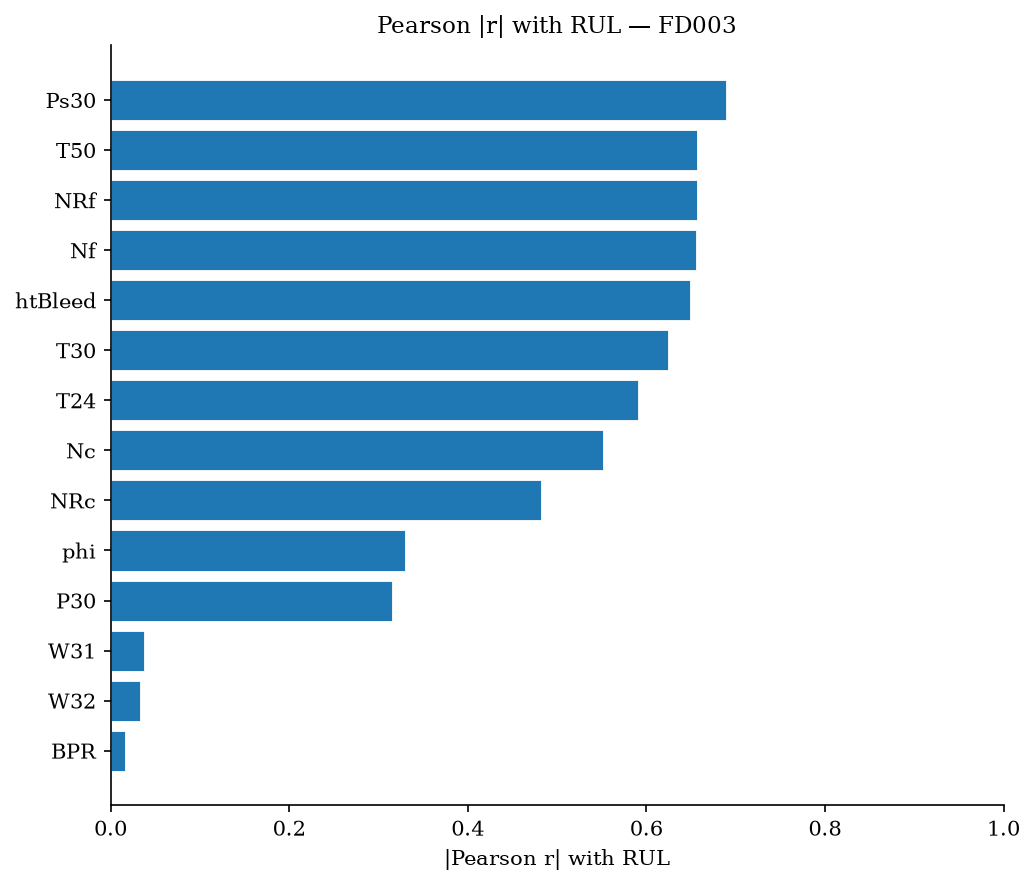

Saved → output/figures/EDA/FD003/pearson_rul_barchart.png


In [5]:
# Bar chart of |Pearson r| with RUL, sorted (single-dataset view of the
# cross-dataset heatmap used in Improved_EDA.ipynb)
plot_df = corr_df.set_index('Sensor')['Pearson_r'].abs().loc[INFORMATIVE].sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(plot_df.index, plot_df.values, color=PALETTE[0], edgecolor='white', linewidth=0.4)
ax.set_xlabel('|Pearson r| with RUL')
ax.set_title(f'Pearson |r| with RUL — {DATASET}', fontsize=11)
ax.set_xlim(0, 1)
plt.tight_layout()
fig.savefig(FIG_DIR / 'pearson_rul_barchart.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/pearson_rul_barchart.png')

---
## 4. Mann-Kendall Trend Test

The **Mann-Kendall test** (Kendall 1975) is a nonparametric test for monotonic trend.
We apply it **per engine** and report:
- `tau`: mean Kendall τ across engines (sign indicates direction; magnitude indicates consistency)
- `sig_frac`: fraction of engines where trend is significant at α = 0.05

Sensors with large `|tau|` and high `sig_frac` are reliable trend carriers.

In [6]:
def mann_kendall_sensor(df, sensor_col, alpha=0.05):
    """Run Mann-Kendall per engine; return mean tau and fraction significant."""
    taus, sigs = [], []
    for uid, grp in df.groupby('unit_id'):
        series = grp.sort_values('cycle')[sensor_col].values
        if len(series) < 4:
            continue
        result = mk.original_test(series, alpha=alpha)
        taus.append(result.Tau)
        sigs.append(1 if result.p < alpha else 0)
    return np.mean(taus), np.mean(sigs)


mk_rows = []
for s in INFORMATIVE:
    tau_mean, sig_frac = mann_kendall_sensor(df_n, s + '_norm')
    mk_rows.append({
        'Dataset': DATASET, 'Sensor': s,
        'MK_tau': round(tau_mean, 4),
        'MK_sig_frac': round(sig_frac, 4),
    })

mk_df = pd.DataFrame(mk_rows)
disp_mk = mk_df.set_index('Sensor').sort_values('MK_sig_frac', ascending=False)
display(disp_mk)
mk_df.to_csv(TABLE_DIR / 'mann_kendall.csv', index=False)
print('Saved → output/tables/EDA/{}/mann_kendall.csv'.format(DATASET))

,Dataset,MK_tau,MK_sig_frac
Sensor,,,
T24,FD003,0.4564,1.00
T30,FD003,0.4593,1.00
T50,FD003,0.5593,1.00
P30,FD003,0.0213,1.00
Nf,FD003,0.6046,1.00
Ps30,FD003,0.6060,1.00
phi,FD003,0.0129,1.00
NRf,FD003,0.6021,1.00
BPR,FD003,0.0413,1.00


Saved → output/tables/EDA/FD003/mann_kendall.csv


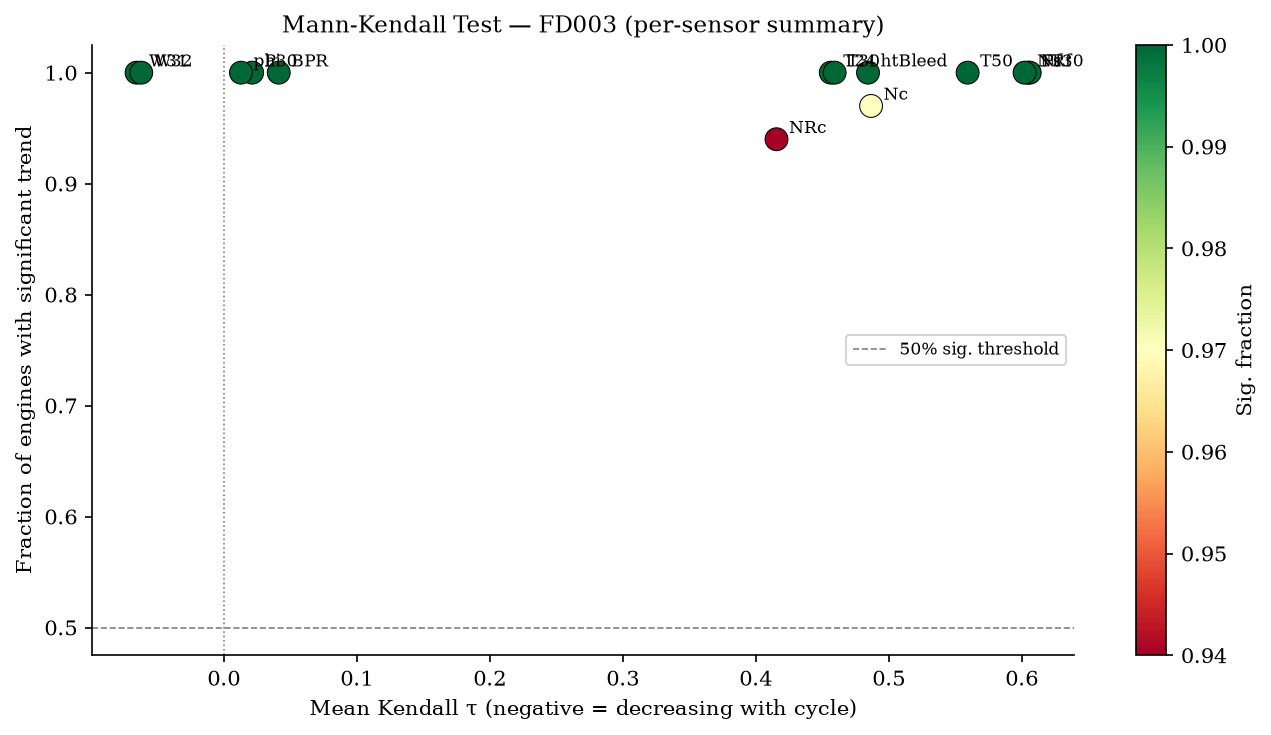

Saved → output/figures/EDA/FD003/mann_kendall_FD003.png


In [7]:
# Bubble chart: MK tau vs significance fraction
mk_r = disp_mk.reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    mk_r['MK_tau'], mk_r['MK_sig_frac'],
    c=mk_r['MK_sig_frac'], cmap='RdYlGn', s=120, edgecolors='k', linewidths=0.5
)
for _, row in mk_r.iterrows():
    ax.annotate(row['Sensor'], (row['MK_tau'], row['MK_sig_frac']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='50% sig. threshold')
ax.axvline(0.0, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Mean Kendall τ (negative = decreasing with cycle)')
ax.set_ylabel('Fraction of engines with significant trend')
ax.set_title(f'Mann-Kendall Test — {DATASET} (per-sensor summary)', fontsize=11)
plt.colorbar(sc, ax=ax, label='Sig. fraction')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / f'mann_kendall_{DATASET}.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/mann_kendall_{DATASET}.png')

---
## 5. Monotonicity Score

**Monotonicity** measures the directional consistency of a sensor's degradation signal within each engine.
For a sequence $x_1, \ldots, x_n$:

$$
\text{Mon}(x) = \left| \frac{\#\{i: x_{i+1} > x_i\} - \#\{i: x_{i+1} < x_i\}}{n-1} \right|
$$

Score ∈ [0, 1].  Score = 1 means perfectly monotone; 0 means symmetric noise.

In [8]:
def monotonicity_score(series: np.ndarray) -> float:
    d = np.diff(series)
    n = len(d)
    if n == 0:
        return np.nan
    return abs((d > 0).sum() - (d < 0).sum()) / n


def sensor_monotonicity(df, sensor_col):
    scores = []
    for uid, grp in df.groupby('unit_id'):
        series = grp.sort_values('cycle')[sensor_col].values
        if len(series) > 1:
            scores.append(monotonicity_score(series))
    return np.mean(scores)


mono_rows = []
for s in INFORMATIVE:
    score = sensor_monotonicity(df_n, s + '_norm')
    mono_rows.append({'Dataset': DATASET, 'Sensor': s, 'Monotonicity': round(score, 4)})

mono_df = pd.DataFrame(mono_rows)
disp_mono = mono_df.set_index('Sensor').sort_values('Monotonicity', ascending=False)
display(disp_mono)
mono_df.to_csv(TABLE_DIR / 'monotonicity_scores.csv', index=False)
print('Saved → output/tables/EDA/{}/monotonicity_scores.csv'.format(DATASET))

,Dataset,Monotonicity
Sensor,,
phi,FD003,0.0526
NRc,FD003,0.0524
P30,FD003,0.0481
Nc,FD003,0.0403
Nf,FD003,0.0353
W31,FD003,0.0339
NRf,FD003,0.0334
Ps30,FD003,0.0325
BPR,FD003,0.0322


Saved → output/tables/EDA/FD003/monotonicity_scores.csv


---
## 6. Trendability Score

**Trendability** measures whether the degradation pattern is consistent **across engines** — i.e. engines degrade in the same direction.
We define it as the mean absolute Pearson correlation between the sensor signal and normalised cycle position $t/T_i \in [0,1]$, averaged across engines:

$$
\text{Trend}(s) = \frac{1}{N}\sum_{i=1}^{N} \left|\text{corr}\left(s_i(t),\; t/T_i\right)\right|
$$

Score ∈ [0, 1]. Score = 1 means every engine shows the same linear trend.

In [9]:
def sensor_trendability(df, sensor_col):
    corrs = []
    for uid, grp in df.groupby('unit_id'):
        grp = grp.sort_values('cycle')
        n = len(grp)
        if n < 4:
            continue
        t_norm = np.linspace(0, 1, n)
        r, _ = stats.pearsonr(grp[sensor_col].values, t_norm)
        if not np.isnan(r):
            corrs.append(abs(r))
    return np.mean(corrs) if corrs else np.nan


trend_rows = []
for s in INFORMATIVE:
    score = sensor_trendability(df_n, s + '_norm')
    trend_rows.append({'Dataset': DATASET, 'Sensor': s, 'Trendability': round(score, 4)})

trend_df = pd.DataFrame(trend_rows)
disp_trend = trend_df.set_index('Sensor').sort_values('Trendability', ascending=False)
display(disp_trend)
trend_df.to_csv(TABLE_DIR / 'trendability_scores.csv', index=False)
print('Saved → output/tables/EDA/{}/trendability_scores.csv'.format(DATASET))

,Dataset,Trendability
Sensor,,
phi,FD003,0.8196
P30,FD003,0.8057
Ps30,FD003,0.7907
T50,FD003,0.7554
Nf,FD003,0.7554
NRf,FD003,0.7532
BPR,FD003,0.7500
NRc,FD003,0.7351
Nc,FD003,0.7291


Saved → output/tables/EDA/FD003/trendability_scores.csv


---
## 7. Mutual Information with RUL

**Mutual Information** captures nonlinear statistical dependence between a sensor and RUL — unlike Pearson correlation it detects any functional relationship.
We use `sklearn.feature_selection.mutual_info_regression` with 5 nearest neighbours.

In [10]:
df_mi = df_n.dropna(subset=NORM_SENSORS + ['RUL'])
X = df_mi[NORM_SENSORS].values
y = df_mi['RUL'].values
mi_vals = mutual_info_regression(X, y, n_neighbors=5, random_state=42)

mi_rows = [{'Dataset': DATASET, 'Sensor': s, 'MI': round(mi, 4)} for s, mi in zip(INFORMATIVE, mi_vals)]
mi_df = pd.DataFrame(mi_rows)
disp_mi = mi_df.set_index('Sensor').sort_values('MI', ascending=False)
display(disp_mi)
mi_df.to_csv(TABLE_DIR / 'mutual_information.csv', index=False)
print('Saved → output/tables/EDA/{}/mutual_information.csv'.format(DATASET))

,Dataset,MI
Sensor,,
Ps30,FD003,0.5577
phi,FD003,0.5125
P30,FD003,0.4981
Nf,FD003,0.4844
NRf,FD003,0.4842
T50,FD003,0.4760
BPR,FD003,0.4493
htBleed,FD003,0.4103
Nc,FD003,0.3763


Saved → output/tables/EDA/FD003/mutual_information.csv


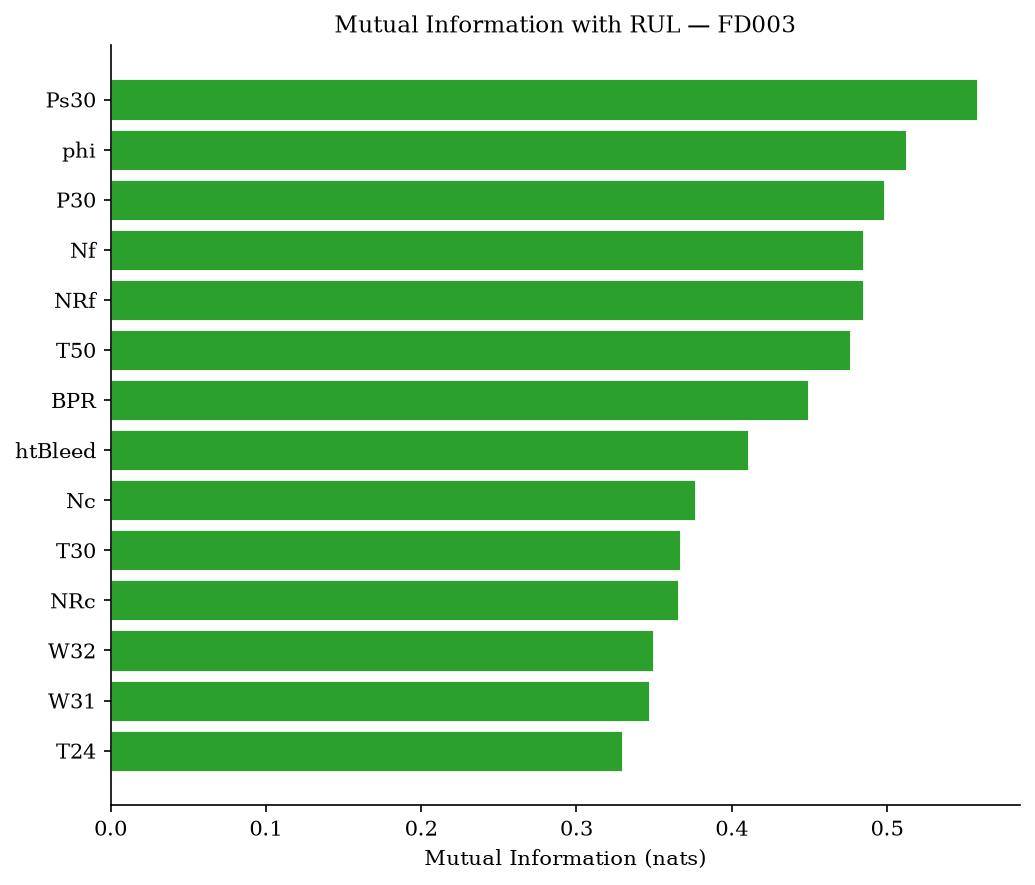

Saved → output/figures/EDA/FD003/mutual_information_barchart.png


In [11]:
# MI bar chart, sorted
plot_df = disp_mi['MI'].sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(plot_df.index, plot_df.values, color=PALETTE[2], edgecolor='white', linewidth=0.4)
ax.set_xlabel('Mutual Information (nats)')
ax.set_title(f'Mutual Information with RUL — {DATASET}', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'mutual_information_barchart.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/mutual_information_barchart.png')

---
## 8. Collinearity — Correlation Matrix & VIF

**VIF** (Variance Inflation Factor) quantifies multicollinearity: how much the variance of a sensor's regression coefficient is inflated by correlation with other sensors.
Rule of thumb: VIF > 10 → severe collinearity; VIF > 5 → moderate concern.
Removing collinear sensors reduces model complexity without losing predictive information.

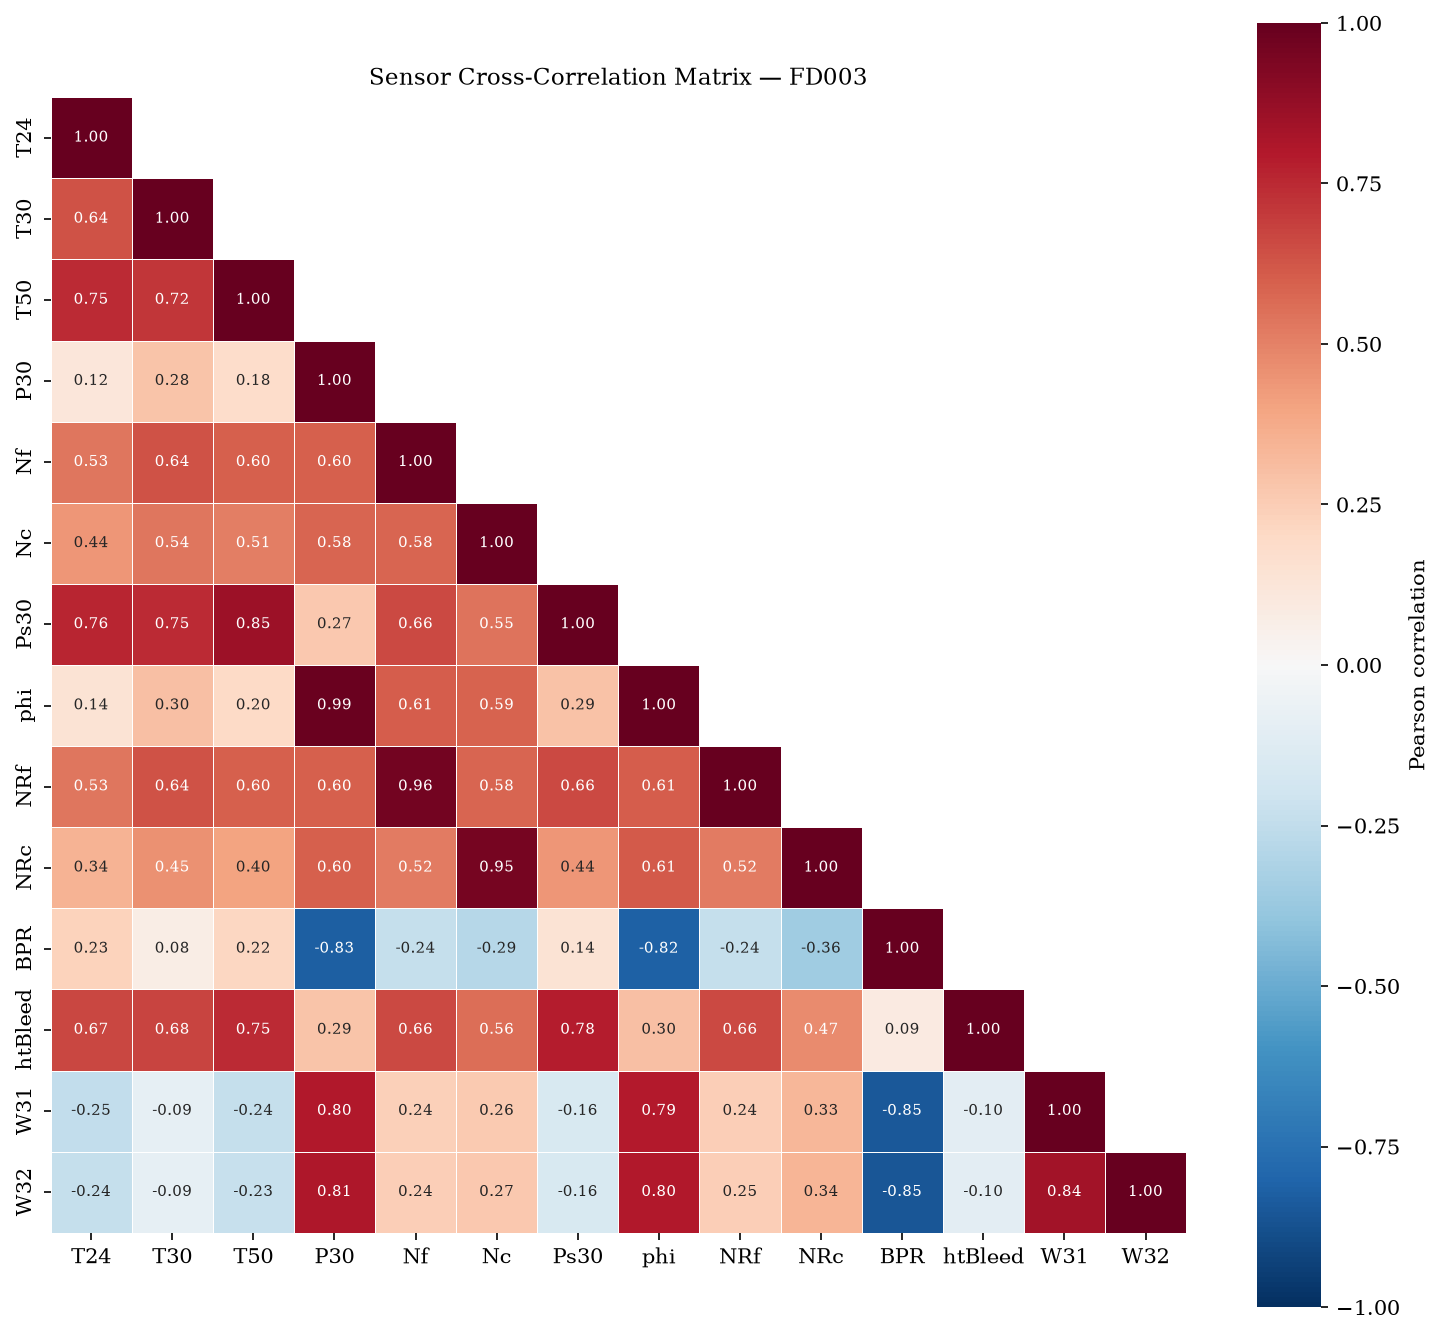

Saved → output/figures/EDA/FD003/sensor_correlation_matrix.png


In [12]:
corr_matrix = df_n[NORM_SENSORS].rename(columns=lambda c: c.replace('_norm', '')).corr()

fig, ax = plt.subplots(figsize=(10, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson correlation'}
)
ax.set_title(f'Sensor Cross-Correlation Matrix — {DATASET}', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sensor_correlation_matrix.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/sensor_correlation_matrix.png')

In [13]:
def compute_vif(df, sensor_cols):
    """Compute VIF for each sensor in sensor_cols using a sampled subset for speed."""
    X = df[sensor_cols].dropna()
    if len(X) > 10_000:
        X = X.sample(10_000, random_state=42)
    X = X.values
    vif_vals = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.Series(vif_vals, index=[c.replace('_norm', '') for c in sensor_cols])


vif = compute_vif(df_n, NORM_SENSORS)
vif_df = pd.DataFrame([{'Dataset': DATASET, 'Sensor': s, 'VIF': round(v, 2)} for s, v in vif.items()])
disp_vif = vif_df.set_index('Sensor').sort_values('VIF', ascending=False)
display(disp_vif)
vif_df.to_csv(TABLE_DIR / 'vif_scores.csv', index=False)
print('Saved → output/tables/EDA/{}/vif_scores.csv'.format(DATASET))

,Dataset,VIF
Sensor,,
phi,FD003,51.21
P30,FD003,47.42
Nc,FD003,15.05
Nf,FD003,14.81
NRf,FD003,14.70
NRc,FD003,13.22
BPR,FD003,6.94
W32,FD003,5.81
Ps30,FD003,5.69


Saved → output/tables/EDA/FD003/vif_scores.csv


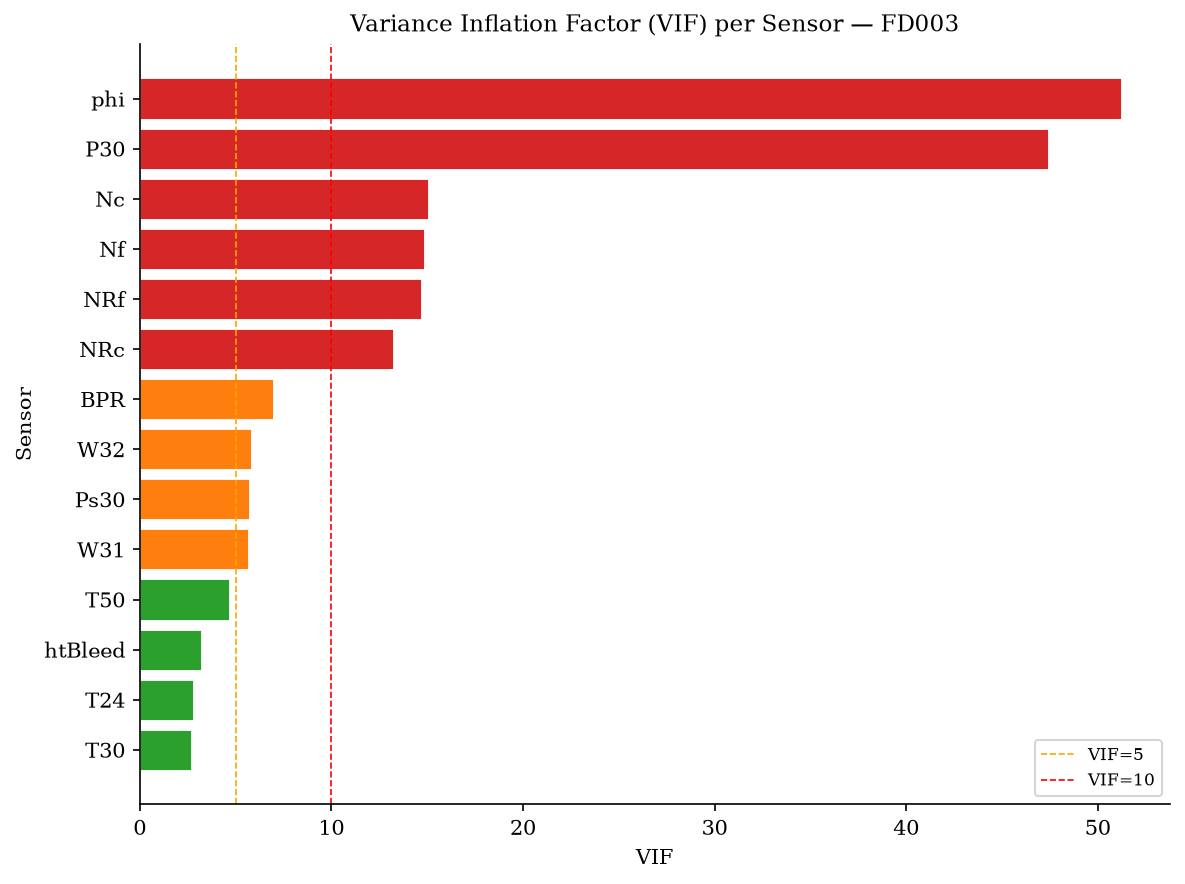

Saved → output/figures/EDA/FD003/vif_barchart.png


In [14]:
# VIF bar chart with severity thresholds
vals = disp_vif['VIF'].loc[INFORMATIVE].sort_values(ascending=True)
colors = ['#d62728' if v > 10 else '#ff7f0e' if v > 5 else '#2ca02c' for v in vals]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(5,  color='orange', linestyle='--', linewidth=0.8, label='VIF=5')
ax.axvline(10, color='red',    linestyle='--', linewidth=0.8, label='VIF=10')
ax.set_title(f'Variance Inflation Factor (VIF) per Sensor — {DATASET}', fontsize=11)
ax.set_xlabel('VIF')
ax.set_ylabel('Sensor')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'vif_barchart.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/vif_barchart.png')

---
## 9. Composite Sensor Ranking

We combine all five criteria into a single composite score by:
1. Normalising each criterion to [0, 1] (min-max), computed within FD003 alone
2. Computing an equally-weighted mean

For VIF, the score is **inverted** (lower VIF = better).
For `MK_sig_frac`, Monotonicity, Trendability, and MI — higher is better.

In [15]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)


base = pd.DataFrame({'Sensor': INFORMATIVE}).set_index('Sensor')
comp = (
    base
    .join(mk_df.set_index('Sensor')[['MK_sig_frac']])
    .join(mono_df.set_index('Sensor')[['Monotonicity']])
    .join(trend_df.set_index('Sensor')[['Trendability']])
    .join(mi_df.set_index('Sensor')[['MI']])
    .join(vif_df.set_index('Sensor')[['VIF']])
)

comp['MK_norm']    = minmax(comp['MK_sig_frac'])
comp['Mono_norm']  = minmax(comp['Monotonicity'])
comp['Trend_norm'] = minmax(comp['Trendability'])
comp['MI_norm']    = minmax(comp['MI'])
comp['VIF_norm']   = 1 - minmax(comp['VIF'])  # inverted: low VIF is good

comp['Composite'] = comp[['MK_norm', 'Mono_norm', 'Trend_norm', 'MI_norm', 'VIF_norm']].mean(axis=1)
comp['Dataset'] = DATASET

disp_comp = comp[['MK_sig_frac', 'Monotonicity', 'Trendability', 'MI', 'VIF', 'Composite']].sort_values('Composite', ascending=False).round(4)
display(disp_comp)
comp.reset_index().to_csv(TABLE_DIR / 'composite_sensor_ranking.csv', index=False)
print('Saved → output/tables/EDA/{}/composite_sensor_ranking.csv'.format(DATASET))

,MK_sig_frac,Monotonicity,Trendability,MI,VIF,Composite
Sensor,,,,,,
Ps30,1.00,0.0325,0.7907,0.5577,5.69,0.8044
phi,1.00,0.0526,0.8196,0.5125,51.21,0.7605
P30,1.00,0.0481,0.8057,0.4981,47.42,0.7137
T50,1.00,0.0320,0.7554,0.4760,4.64,0.6916
Nf,1.00,0.0353,0.7554,0.4844,14.81,0.6815
NRf,1.00,0.0334,0.7532,0.4842,14.70,0.6651
BPR,1.00,0.0322,0.7500,0.4493,6.94,0.6539
W31,1.00,0.0339,0.7109,0.3470,5.63,0.5360
htBleed,1.00,0.0259,0.6930,0.4103,3.19,0.5209


Saved → output/tables/EDA/FD003/composite_sensor_ranking.csv


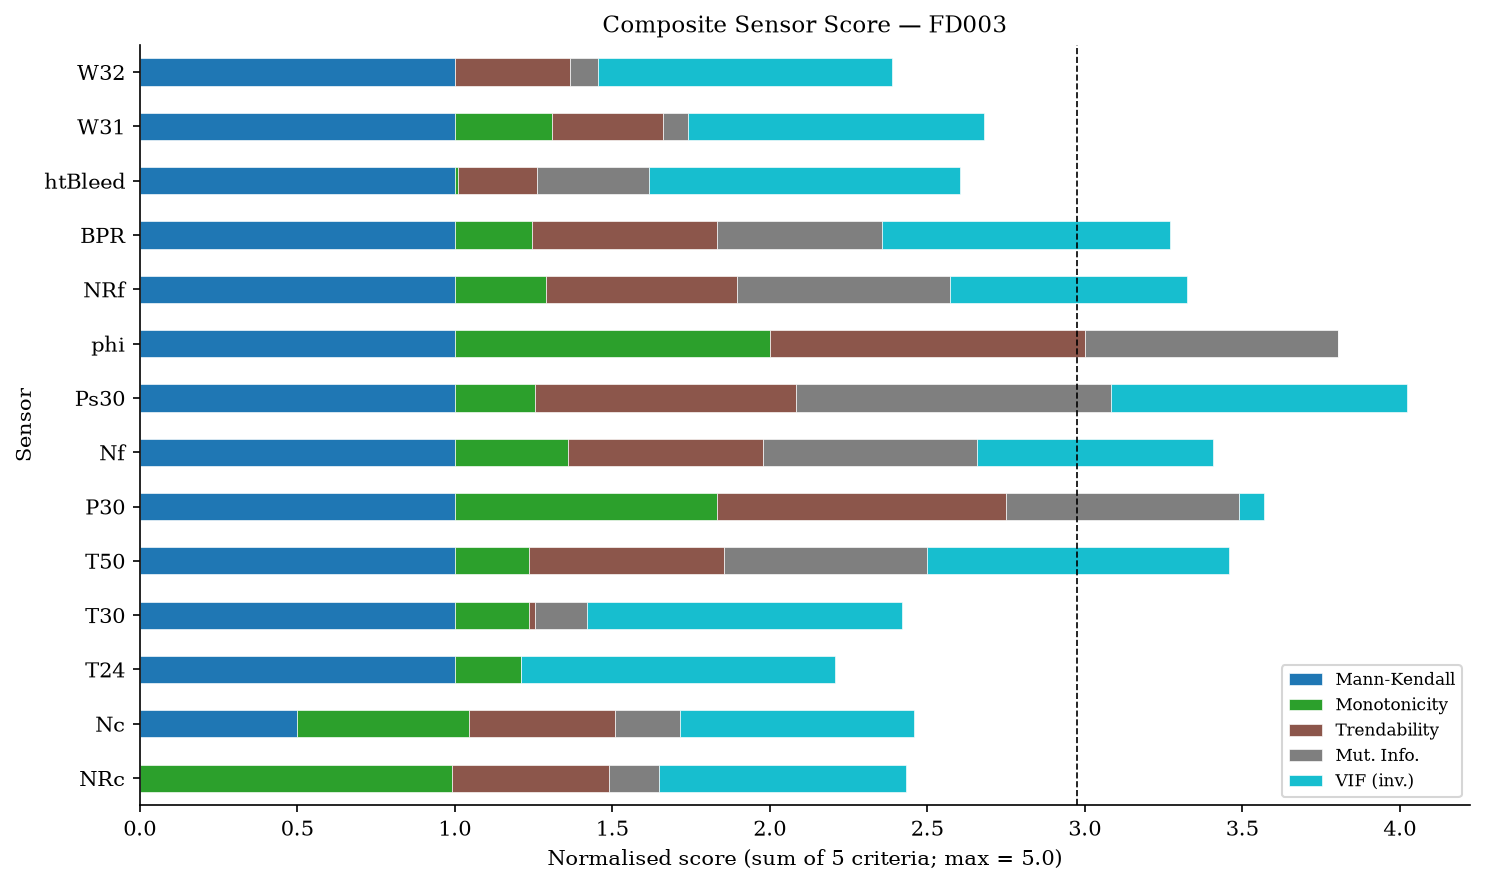

Saved → output/figures/EDA/FD003/composite_ranking_FD003.png


In [16]:
# Stacked bar chart of normalised criteria per sensor
criteria_cols = ['MK_norm', 'Mono_norm', 'Trend_norm', 'MI_norm', 'VIF_norm']
criteria_labels = ['Mann-Kendall', 'Monotonicity', 'Trendability', 'Mut. Info.', 'VIF (inv.)']

plot_df = comp[criteria_cols].sort_values('MK_norm', ascending=True).copy()
plot_df.columns = criteria_labels

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind='barh', stacked=True, ax=ax, colormap='tab10', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Normalised score (sum of 5 criteria; max = 5.0)')
ax.set_title(f'Composite Sensor Score — {DATASET}', fontsize=11)
ax.legend(loc='lower right', fontsize=8)
ax.axvline(plot_df.sum(axis=1).median(), color='k', linestyle='--', linewidth=0.8, label='Median')
plt.tight_layout()
fig.savefig(FIG_DIR / f'composite_ranking_{DATASET}.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/composite_ranking_{DATASET}.png')

---
## 10. Final Sensor Selection

### Selection rules

1. **Composite score ≥ 0.40** (FD003 alone — for a single sub-dataset there is no cross-dataset mean to average over, unlike `Improved_EDA.ipynb`'s 4-dataset version)
2. **VIF ≤ 10** — removes collinear duplicates
3. Among sensors surviving (1)+(2), if two are highly correlated (|r| > 0.90), keep the one with higher composite score

The resulting list is FD003's sensor subset under this pipeline.

In [17]:
# Step 1: composite threshold
THRESHOLD_COMP = 0.40
step1 = comp[comp['Composite'] >= THRESHOLD_COMP].index.tolist()
print(f'After composite >= {THRESHOLD_COMP}: {step1}')

After composite >= 0.4: ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']


In [18]:
# Step 2: VIF filter
step2 = [s for s in step1 if comp.loc[s, 'VIF'] <= 10]
print(f'After VIF <= 10: {step2}')

removed_vif = [s for s in step1 if s not in step2]
print(f'Removed by VIF: {removed_vif}')

After VIF <= 10: ['T24', 'T30', 'T50', 'Ps30', 'BPR', 'htBleed', 'W31', 'W32']
Removed by VIF: ['P30', 'Nf', 'Nc', 'phi', 'NRf', 'NRc']


In [19]:
# Step 3: Remove within-group collinear duplicates (|r| > 0.90)
corr_sub = df_n[[s + '_norm' for s in step2]].rename(columns=lambda c: c.replace('_norm', '')).corr().abs()

to_drop = set()
for i, s1 in enumerate(step2):
    for s2 in step2[i+1:]:
        if s1 in to_drop or s2 in to_drop:
            continue
        r = corr_sub.loc[s1, s2] if s1 in corr_sub.index and s2 in corr_sub.columns else 0
        if r > 0.90:
            drop = s1 if comp.loc[s1, 'Composite'] < comp.loc[s2, 'Composite'] else s2
            to_drop.add(drop)
            print(f'|r|({s1},{s2}) = {r:.2f} → dropping {drop}')

SELECTED_SENSORS = [s for s in step2 if s not in to_drop]
print(f'\nFinal selected sensors for {DATASET} ({len(SELECTED_SENSORS)}): {SELECTED_SENSORS}')


Final selected sensors for FD003 (8): ['T24', 'T30', 'T50', 'Ps30', 'BPR', 'htBleed', 'W31', 'W32']


In [20]:
# Save the final sensor list
pd.Series(SELECTED_SENSORS, name='sensor').to_csv(TABLE_DIR / 'selected_sensors.csv', index=False)
print('Saved → output/tables/EDA/{}/selected_sensors.csv'.format(DATASET))

final_table = (
    comp[['MK_sig_frac', 'Monotonicity', 'Trendability', 'MI', 'VIF', 'Composite']]
    .loc[SELECTED_SENSORS]
    .sort_values('Composite', ascending=False)
    .round(4)
)
final_table['Selected'] = True
display(final_table)
final_table.to_csv(TABLE_DIR / 'final_sensor_table.csv')
print('Saved → output/tables/EDA/{}/final_sensor_table.csv'.format(DATASET))

Saved → output/tables/EDA/FD003/selected_sensors.csv


,MK_sig_frac,Monotonicity,Trendability,MI,VIF,Composite,Selected
Sensor,,,,,,,
Ps30,1.0,0.0325,0.7907,0.5577,5.69,0.8044,True
T50,1.0,0.0320,0.7554,0.4760,4.64,0.6916,True
BPR,1.0,0.0322,0.7500,0.4493,6.94,0.6539,True
W31,1.0,0.0339,0.7109,0.3470,5.63,0.5360,True
htBleed,1.0,0.0259,0.6930,0.4103,3.19,0.5209,True
T30,1.0,0.0320,0.6542,0.3667,2.67,0.4841,True
W32,1.0,0.0256,0.7125,0.3493,5.81,0.4777,True
T24,1.0,0.0313,0.6511,0.3290,2.79,0.4417,True


Saved → output/tables/EDA/FD003/final_sensor_table.csv


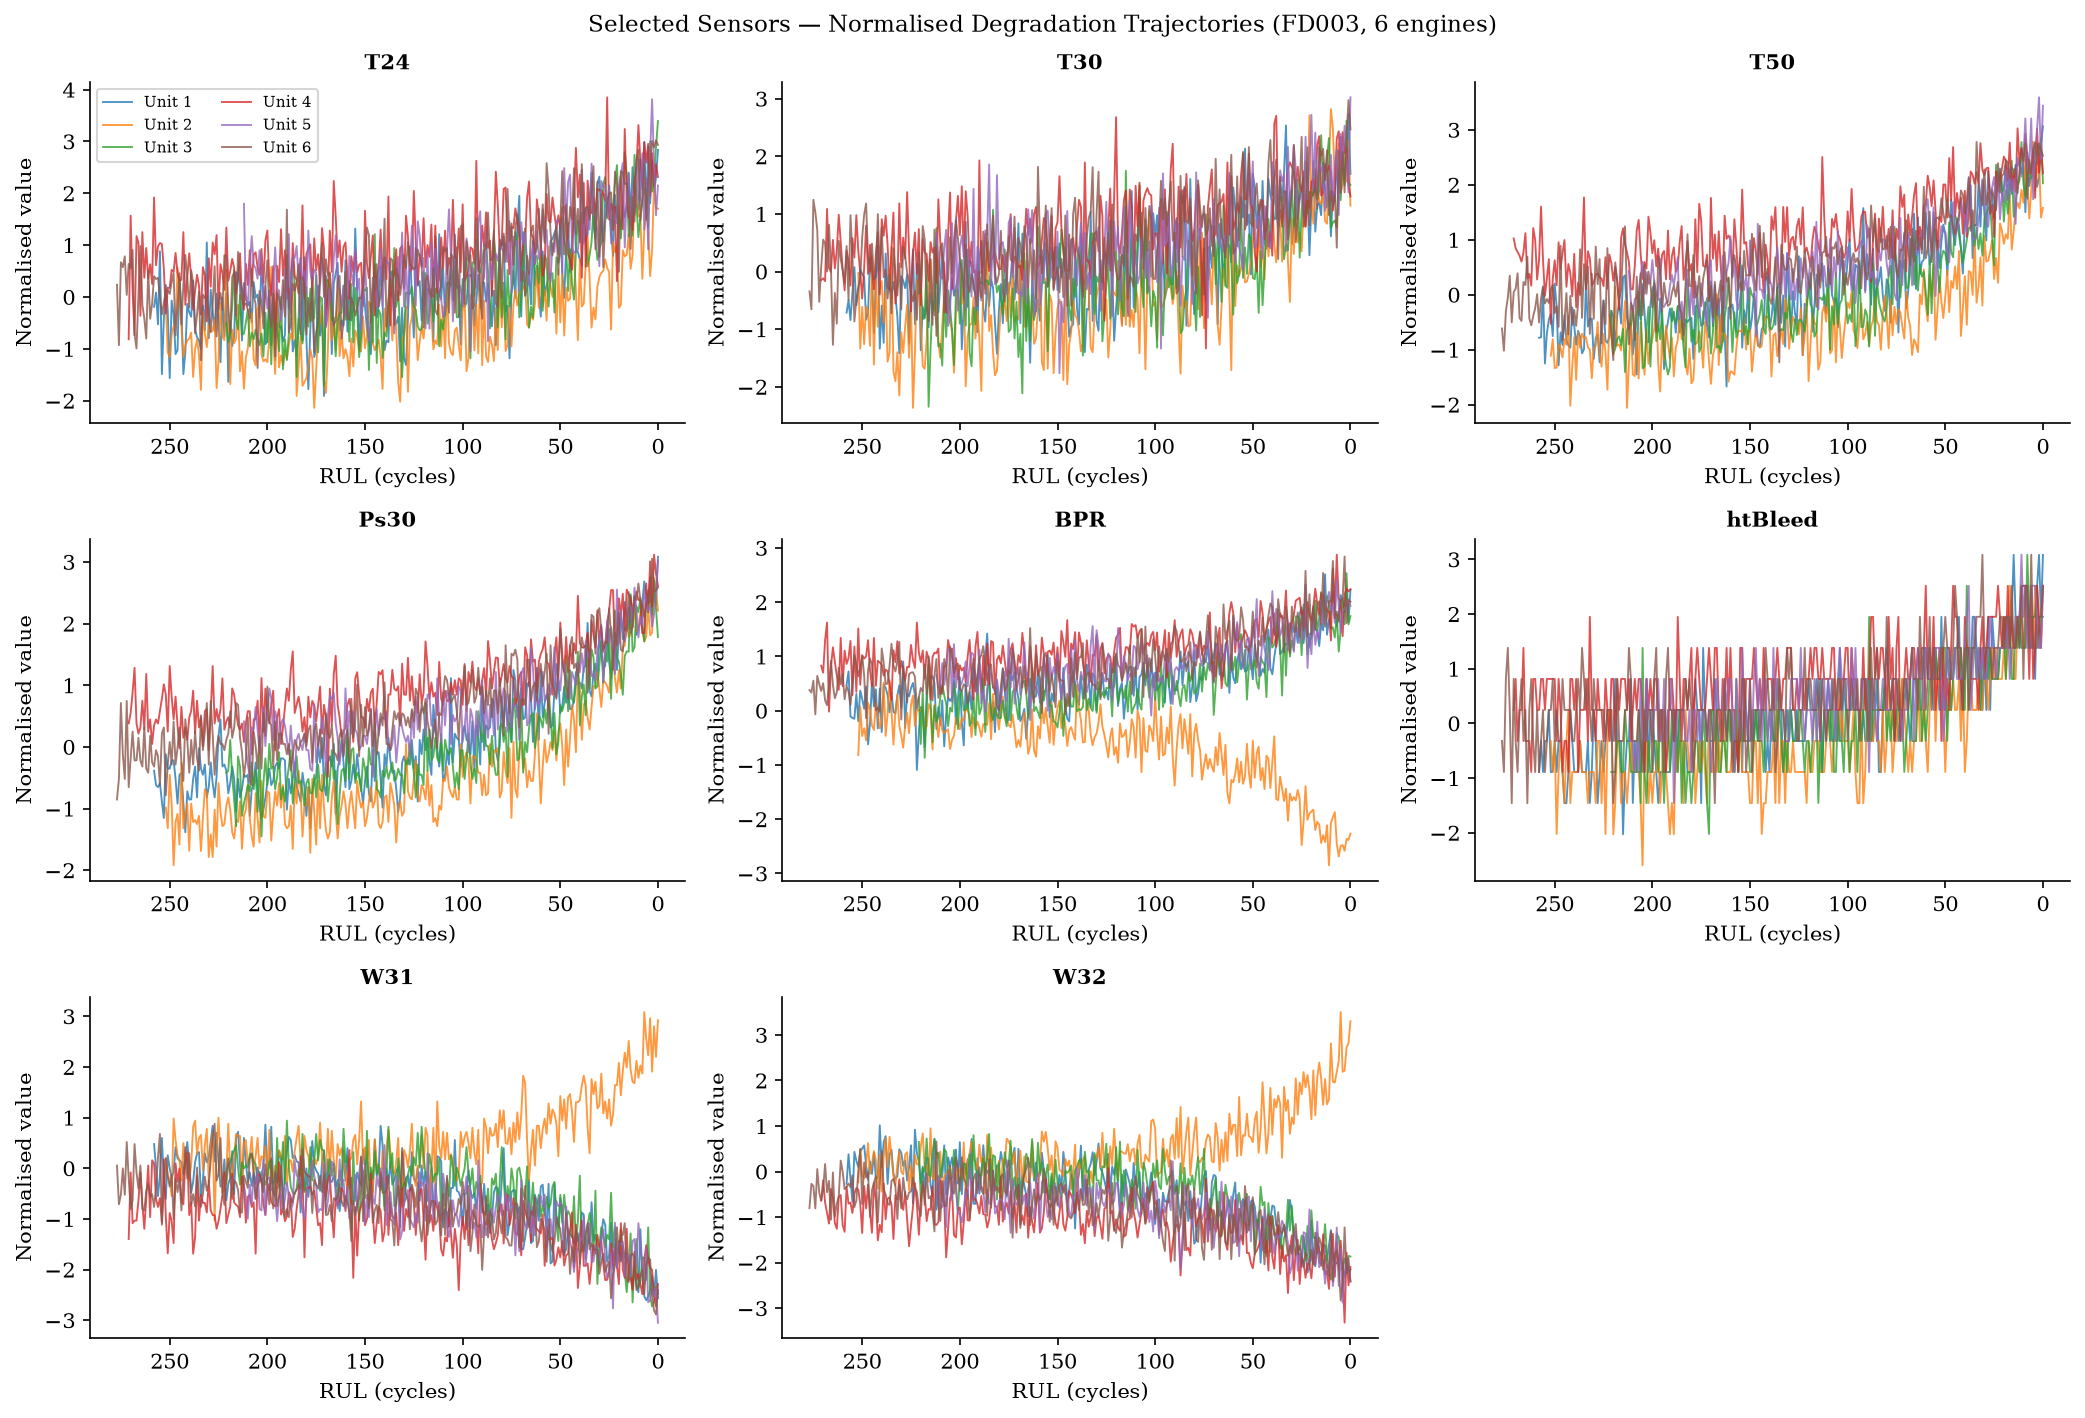

Saved → output/figures/EDA/FD003/selected_sensor_trajectories.png


In [21]:
# Degradation trajectories for selected sensors — sample engines
sample_units = list(df['unit_id'].unique()[:6])

n_sel = len(SELECTED_SENSORS)
ncols = 3
nrows = int(np.ceil(n_sel / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes = np.array(axes).reshape(-1)
fig.suptitle(f'Selected Sensors — Normalised Degradation Trajectories ({DATASET}, 6 engines)', fontsize=11)

for i, s in enumerate(SELECTED_SENSORS):
    ax = axes[i]
    for j, uid in enumerate(sample_units):
        grp = df_n[df_n['unit_id'] == uid].sort_values('cycle')
        ax.plot(grp['RUL'], grp[s + '_norm'],
                linewidth=0.9, alpha=0.8, color=PALETTE[j], label=f'Unit {uid}')
    ax.invert_xaxis()
    ax.set_title(s, fontsize=10, fontweight='bold')
    ax.set_xlabel('RUL (cycles)')
    ax.set_ylabel('Normalised value')
    if i == 0:
        ax.legend(fontsize=7, ncol=2)

for j in range(n_sel, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'selected_sensor_trajectories.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/selected_sensor_trajectories.png')

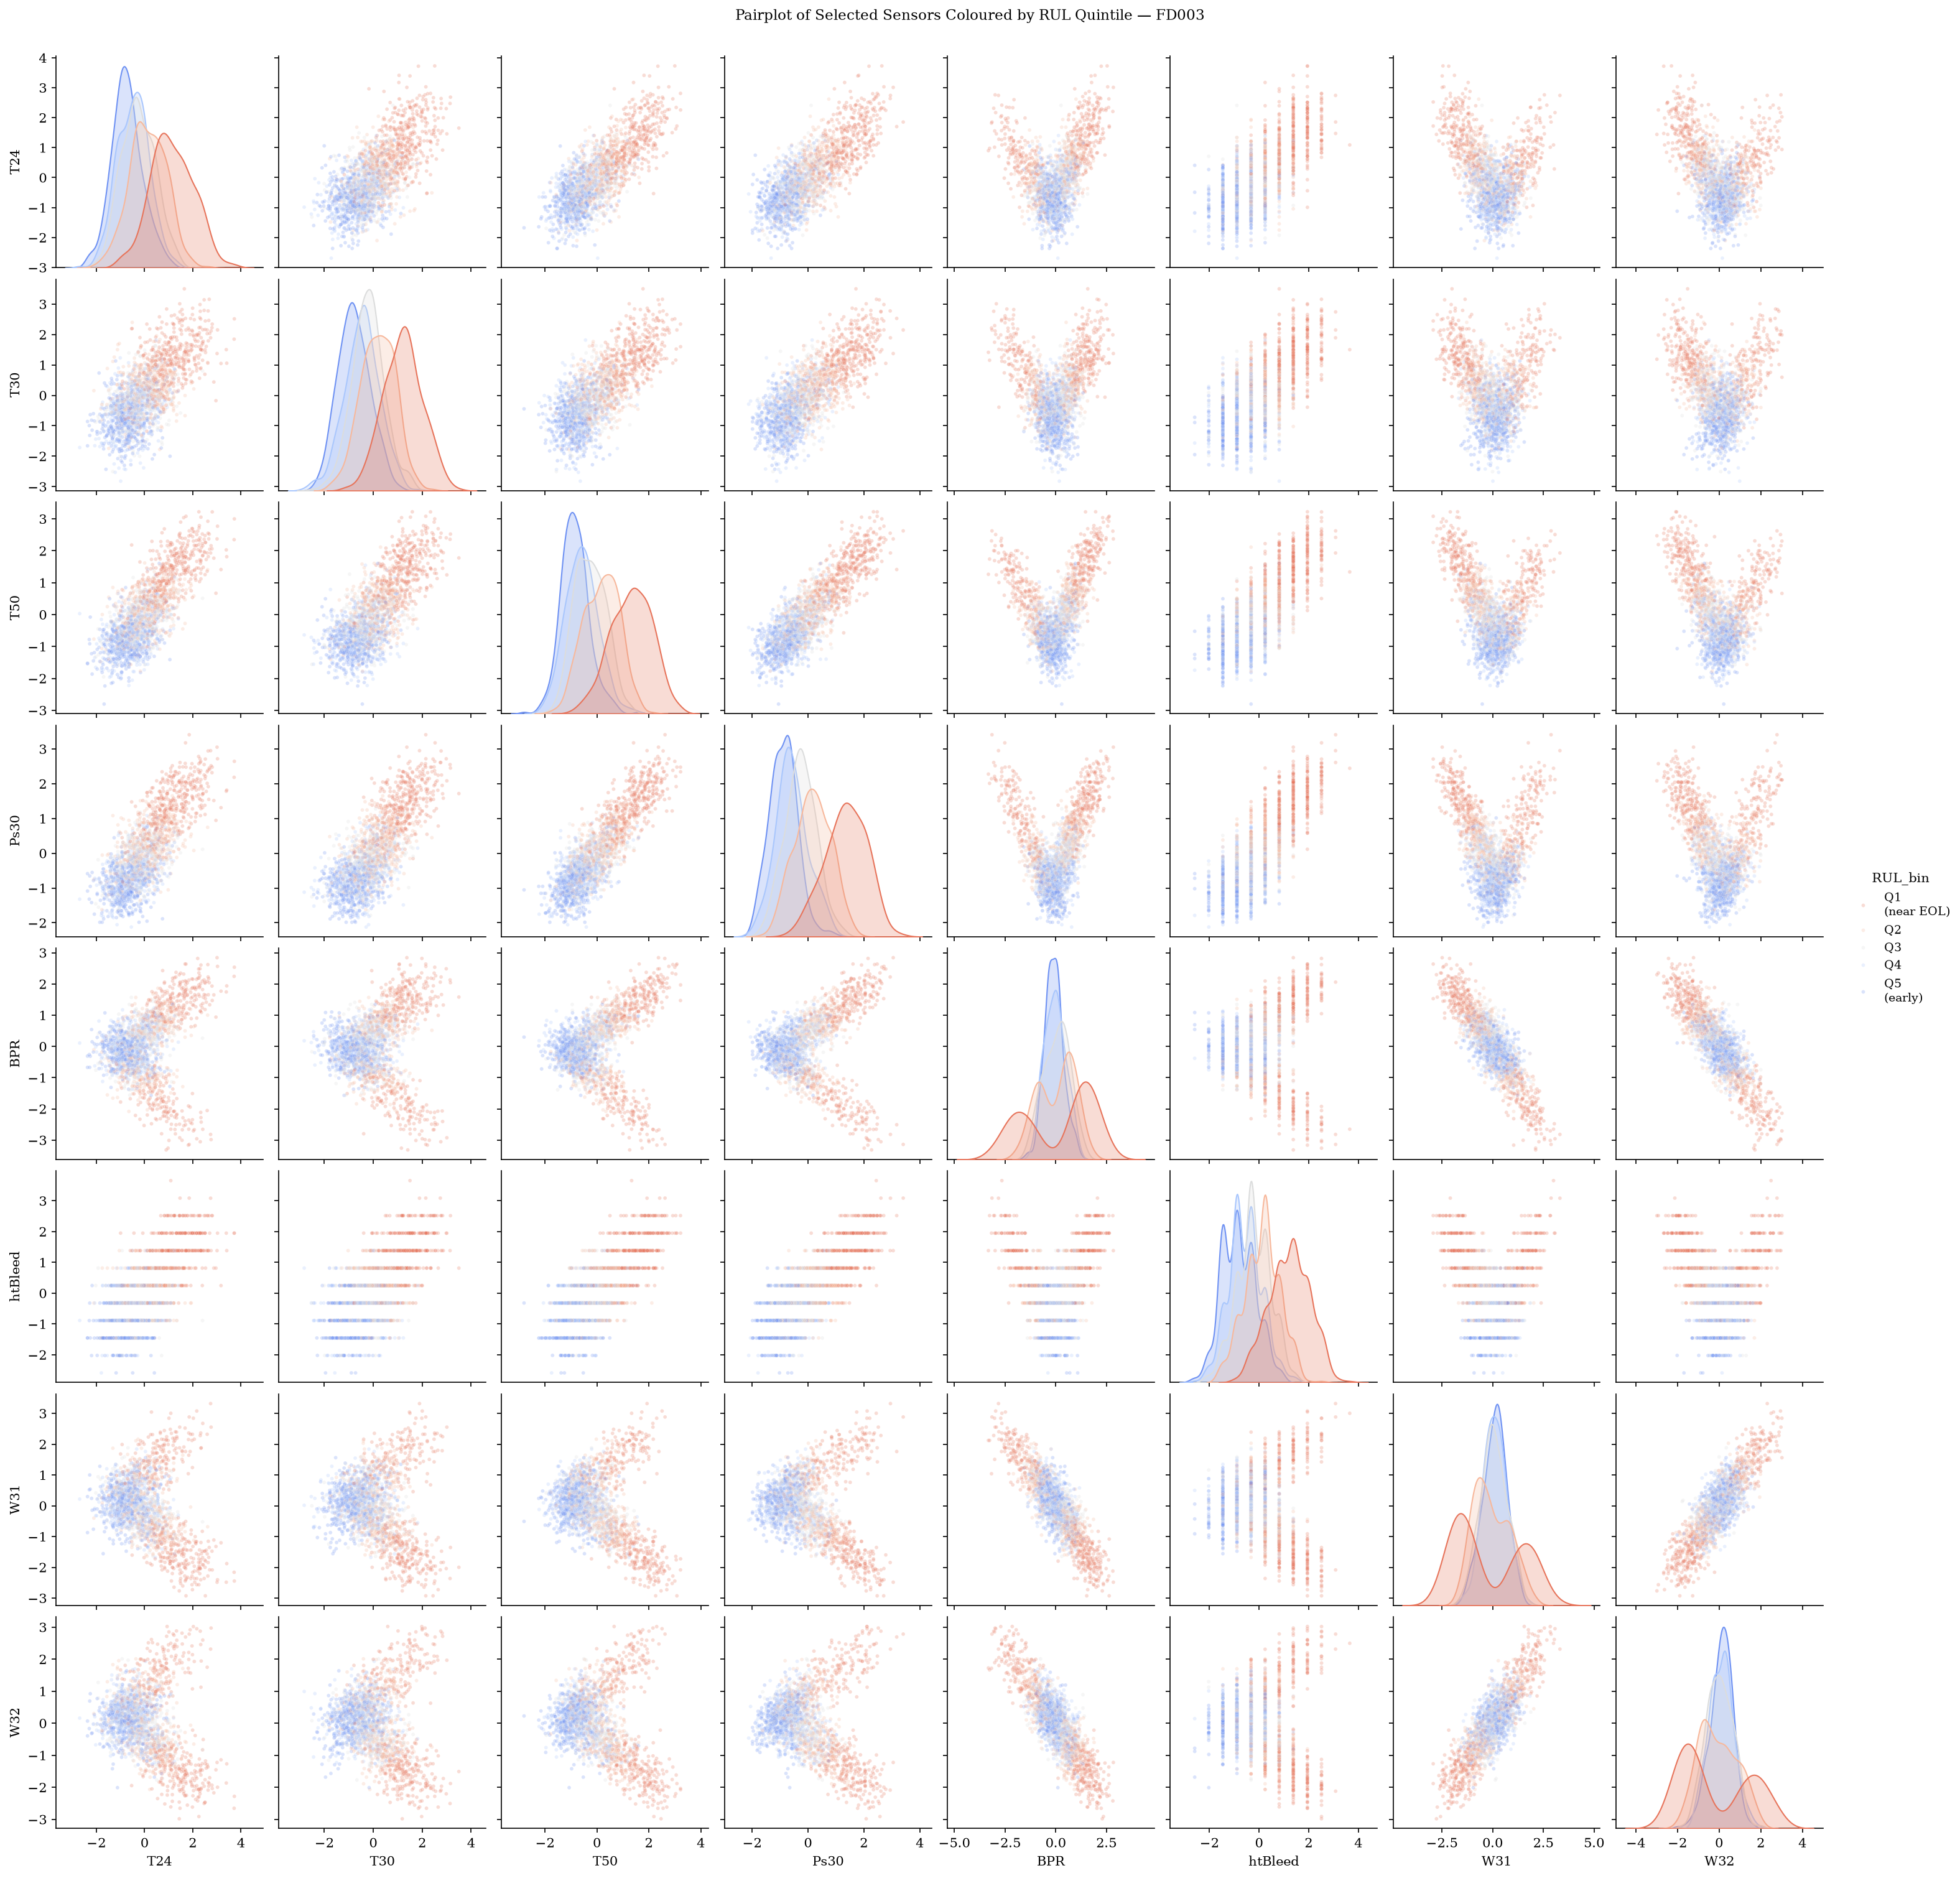

Saved → output/figures/EDA/FD003/selected_sensor_pairplot.png


In [22]:
# Pairplot of selected sensors coloured by RUL quintile (subsample)
n_sample = min(2000, len(df_n))
df_sample = df_n[[s + '_norm' for s in SELECTED_SENSORS] + ['RUL']].sample(n_sample, random_state=42).copy()
df_sample.columns = [c.replace('_norm', '') for c in df_sample.columns]
df_sample['RUL_bin'] = pd.qcut(df_sample['RUL'], q=5, labels=['Q1\n(near EOL)', 'Q2', 'Q3', 'Q4', 'Q5\n(early)'])

g = sns.pairplot(
    df_sample, vars=SELECTED_SENSORS, hue='RUL_bin',
    plot_kws={'alpha': 0.25, 's': 8},
    diag_kind='kde',
    palette='coolwarm_r'
)
g.figure.suptitle(f'Pairplot of Selected Sensors Coloured by RUL Quintile — {DATASET}', y=1.01, fontsize=11)
g.figure.savefig(FIG_DIR / 'selected_sensor_pairplot.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/EDA/{DATASET}/selected_sensor_pairplot.png')

---
## 11. Summary & Conclusions

In [23]:
print('=' * 65)
print(f'  EDA SUMMARY — {DATASET}')
print('=' * 65)

print(f"""
INPUT:  {len(INFORMATIVE)} informative sensors (after removing 7 constant sensors in IDA)
OUTPUT: {len(SELECTED_SENSORS)} selected sensors for {DATASET}

SELECTED SENSORS:
  {SELECTED_SENSORS}

SELECTION PIPELINE:
  1. Mann-Kendall test   — sig. fraction per sensor averaged over engines
  2. Monotonicity score  — directional consistency within each engine
  3. Trendability score  — degradation consistency across engines
  4. Mutual Information  — nonlinear relevance to RUL
  5. VIF (<= 10)         — collinearity filter
  6. |r| > 0.90          — pairwise redundancy removal

OPERATING CONDITIONS
  {DATASET}: single regime ({n_clusters} cluster found) — no normalisation strictly needed,
  z-scoring applied for methodological consistency with the multi-condition sub-datasets.

NEXT STEP
  Compare against EDA_FD001.ipynb and particle_twin's canonical SENSOR_COLS
  to see how sensor selection varies with fault mode (FD003 vs FD001).
""")

  EDA SUMMARY — FD003

INPUT:  14 informative sensors (after removing 7 constant sensors in IDA)
OUTPUT: 8 selected sensors for FD003

SELECTED SENSORS:
  ['T24', 'T30', 'T50', 'Ps30', 'BPR', 'htBleed', 'W31', 'W32']

SELECTION PIPELINE:
  1. Mann-Kendall test   — sig. fraction per sensor averaged over engines
  2. Monotonicity score  — directional consistency within each engine
  3. Trendability score  — degradation consistency across engines
  4. Mutual Information  — nonlinear relevance to RUL
  5. VIF (<= 10)         — collinearity filter
  6. |r| > 0.90          — pairwise redundancy removal

OPERATING CONDITIONS
  FD003: single regime (2 cluster found) — no normalisation strictly needed,
  z-scoring applied for methodological consistency with the multi-condition sub-datasets.

NEXT STEP
  Compare against EDA_FD001.ipynb and particle_twin's canonical SENSOR_COLS
  to see how sensor selection varies with fault mode (FD003 vs FD001).



---
*End of EDA notebook. All tables and figures saved to `output/tables/EDA/FD003/` and `output/figures/EDA/FD003/`.*